In [ ]:
from google.colab import files
uploaded=files.upload()

Saving MNIST_ORG.zip to MNIST_ORG.zip


/tmp/ipython-input-9-2161890772.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features=torch.tensor(features,dtype=torch.float32)
/tmp/ipython-input-9-2161890772.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels=torch.tensor(labels,dtype=torch.long)


Epoch 1/20, Loss: 0.6937, accuracy:95.12%
Epoch 2/20, Loss: 0.6003, accuracy:98.54%
Epoch 3/20, Loss: 0.5875, accuracy:98.86%
Epoch 4/20, Loss: 0.5800, accuracy:99.17%
Epoch 5/20, Loss: 0.5749, accuracy:99.24%
Epoch 6/20, Loss: 0.5660, accuracy:99.44%
Epoch 7/20, Loss: 0.5630, accuracy:99.52%
Epoch 8/20, Loss: 0.5625, accuracy:99.56%
Epoch 9/20, Loss: 0.5612, accuracy:99.57%
Epoch 10/20, Loss: 0.5601, accuracy:99.61%
Epoch 11/20, Loss: 0.5566, accuracy:99.68%
Epoch 12/20, Loss: 0.5559, accuracy:99.71%
Epoch 13/20, Loss: 0.5550, accuracy:99.74%
Epoch 14/20, Loss: 0.5548, accuracy:99.72%
Epoch 15/20, Loss: 0.5540, accuracy:99.71%
Epoch 16/20, Loss: 0.5523, accuracy:99.78%
Epoch 17/20, Loss: 0.5518, accuracy:99.77%
Epoch 18/20, Loss: 0.5515, accuracy:99.81%
Epoch 19/20, Loss: 0.5519, accuracy:99.80%
Epoch 20/20, Loss: 0.5510, accuracy:99.78%
Test loss : 0.5364, Accuracy: 99.29%


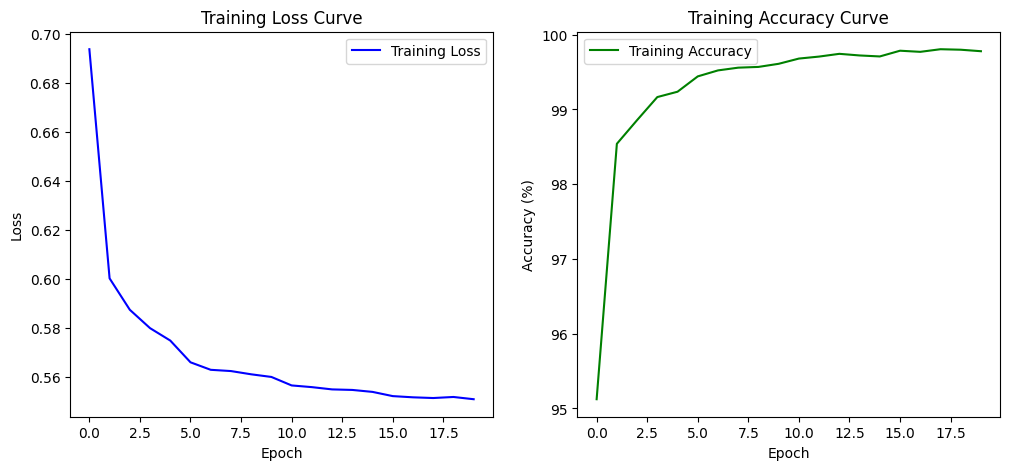

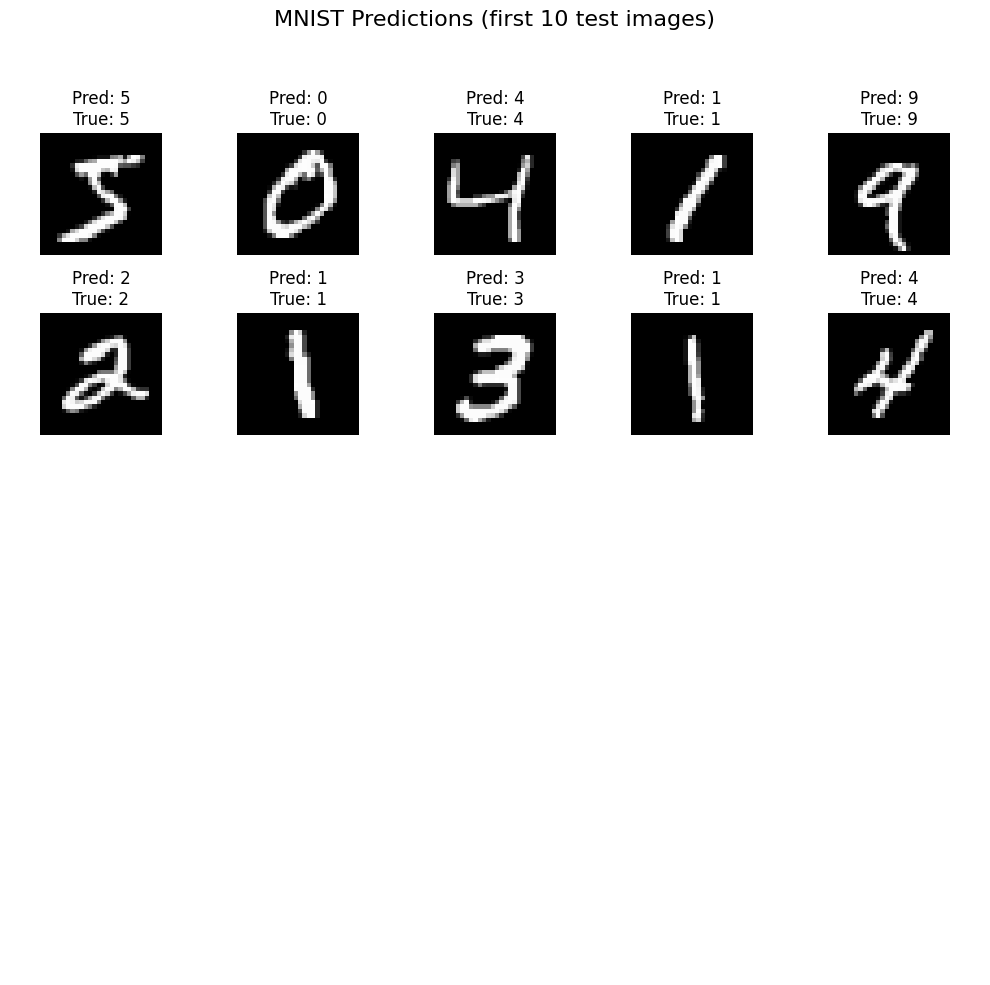

In [ ]:
#importing libraries
!pip install idx2numpy
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
# Import idx2numpy
import idx2numpy

import zipfile
#extracting file data from zip file
with zipfile.ZipFile("MNIST_ORG.zip",'r') as zip_ref:
  zip_ref.extractall("mnist_data")
import os
os.listdir("mnist_data")
#converting idx datafile into numpy file
images=idx2numpy.convert_from_file("mnist_data/train-images.idx3-ubyte")
labels=idx2numpy.convert_from_file('mnist_data/train-labels.idx1-ubyte')
timages=idx2numpy.convert_from_file('mnist_data/t10k-images.idx3-ubyte')
tlabels=idx2numpy.convert_from_file('mnist_data/t10k-labels.idx1-ubyte')

#convert numpyarray into tensor and scaling features
images = torch.tensor(images / 255.0, dtype=torch.float32).unsqueeze(1)
labels = torch.tensor(labels, dtype=torch.long)
timages=torch.tensor(timages/255.0,dtype=torch.float32).unsqueeze(1)
tlabels=torch.tensor(tlabels,dtype=torch.long)

#standarise the dataset
mean, std = images.mean(), images.std()

images = (images - mean) / std
timages = (timages - mean) / std

torch.manual_seed(42)
#setting up device to cuda

device=torch.device('cuda'if torch.cuda.is_available() else 'cpu')
 #creating custom dataset
class customdataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)
  def __getitem__(self,index):
    return self.features[index],self.labels[index]
  def __len__(self):
    return len(self.features)

traindataset=customdataset(images,labels)
testdataset=customdataset(timages,tlabels)

#loading the dataset and assigning batch size
trainloader=DataLoader(traindataset,batch_size=32,shuffle=True ,pin_memory=True)
testloader=DataLoader(testdataset,batch_size=32,shuffle=False, pin_memory=True)

#creating the nn network
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 32x7x7
        )
        self.fc = nn.Sequential(
            nn.Linear(32*7*7, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


#initialising parameters
learning_rate=0.001
epoches=20

#creating model
model = CNN()
model=model.to(device)

#loss function defined
loss_fn=nn.CrossEntropyLoss(label_smoothing= 0.1)

#using optimization technique ADAM (could have used momentum ,SGD , RMS prop but found it working better)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses = []
train_accuracies = []

#starting training model
for epoch in range(epoches):
  total_epoch_loss=0
  correct=0
  total=0
  for batch_features,batch_labels in trainloader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    #getting prediction from model(forward propogation)
    pred=model(batch_features)
    #calculating loss
    loss=loss_fn(pred,batch_labels)
     # zero out gradient
    optimizer.zero_grad()
    #backpropogation
    loss.backward()
    #this i also don't know the use , just found it as a solution to overcome 'exploding gradient' problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
     #call to use optimising technique and updating parameters
    optimizer.step()
     #calculating loss and accuracy
    total_epoch_loss+=loss.item()
    correct += (torch.argmax(pred,dim=1) == batch_labels).sum().item()
    total += batch_labels.size(0)
  scheduler.step()
  acc=100.*correct/total
  avg_epoch_loss=total_epoch_loss/len(trainloader)
  train_losses.append(avg_epoch_loss)
  train_accuracies.append(acc)
  print(f"Epoch {epoch+1}/{epoches}, Loss: {avg_epoch_loss:.4f}, accuracy:{acc:.2f}%")

#it is a call to tell that model will now be evaluated on test set
model.eval()

tcorrect=0
ttotal=0
tloss=0
#taking 10 images from test data for prediction
simages, slabels = next(iter(testloader))
simages, slabels = images[:10], labels[:10]
simages = simages.to(device)

with torch.no_grad():
  for batch_features,batch_labels in testloader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    output=model(batch_features)
    loss=loss_fn(output,batch_labels)
    tloss+=loss.item()
    tcorrect+=(torch.argmax(output,dim=1)==batch_labels).sum().item()
    ttotal+=batch_labels.size(0)
avg_test_loss=tloss/len(testloader)
tacc=100.*tcorrect/ttotal

print(f"Test loss : {avg_test_loss:.4f}, Accuracy: {tacc:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss", color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Training Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve")
plt.legend()

plt.show()

model.eval()
with torch.no_grad():
    soutputs = model(simages)
    _, spreds = soutputs.max(1)

simages = simages.cpu()
spreds = spreds.cpu()
slabels = slabels.cpu()

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('MNIST Predictions (first 10 test images)', fontsize=16)

for i in range(25):
    ax = axes[i // 5, i % 5]
    ax.axis('off')

    if i < 10:
        img = simages[i].squeeze(0)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Pred: {spreds[i]}\nTrue: {slabels[i]}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()